In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("telco_cleaned.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df["TotalCharges"]= df["TotalCharges"].fillna(df["TotalCharges"].median())

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

# Feature Engineering  
Creating Meaningful Business Features.

In [11]:
 df["AvgMonthlySpend"] = (df["TotalCharges"] /(df["tenure"]+1))
service_cols=[
"PhoneService",
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies"
]
df["TotalServices"]=(df[service_cols].eq("Yes").sum(axis=1))
df["CustomerValue"]=(df["MonthlyCharges"]*df["tenure"])
df["LongTerm"]=(df["tenure"]>=24).astype(int)
df["RevenuePerService"] = (df["MonthlyCharges"] /(df["TotalServices"]+1))
df["TenureGroup"] = pd.cut(df["tenure"],bins=[-1,12,24,48,72],labels=[1,2,3,4])
df["TenureGroup"] = (df["TenureGroup"].astype("int64"))
df["SpendingLevel"] = pd.cut(df["MonthlyCharges"],bins=3,labels=[1,2,3])
df["SpendingLevel"] = (df["SpendingLevel"].astype("int64"))

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TotalServices,CustomerValue,LongTerm,RevenuePerService,TenureGroup,SpendingLevel
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,14.925000,1,29.85,0,14.9250,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,53.985714,3,1936.30,1,14.2375,3,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,36.050000,3,107.70,0,13.4625,1,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,40.016304,3,1903.50,1,10.5750,3,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,50.550000,1,141.40,0,35.3500,1,2


In [13]:
X = df.drop(columns=["Churn","customerID"])

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [15]:
print(cat_cols)
print(num_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlySpend', 'TotalServices', 'CustomerValue', 'LongTerm',
       'RevenuePerService', 'TenureGroup', 'SpendingLevel'],
      dtype='object')


# Encoding

In [17]:
encoder = ColumnTransformer(
[("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),cat_cols)],remainder="passthrough")

In [18]:
X_encoded = encoder.fit_transform(X)

# Feature scaleing

In [20]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_encoded)

# Apply PCA (Principal Component Analysis)

In [22]:
pca = PCA(n_components=0.60,random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [23]:
print(
X_pca.shape
)

(7043, 4)


In [24]:
wcss=[]

for k in range(1,11):

    model=KMeans(
    n_clusters=k,
    random_state=42
    )

    model.fit(
    X_pca
    )

    wcss.append(
    model.inertia_
    )

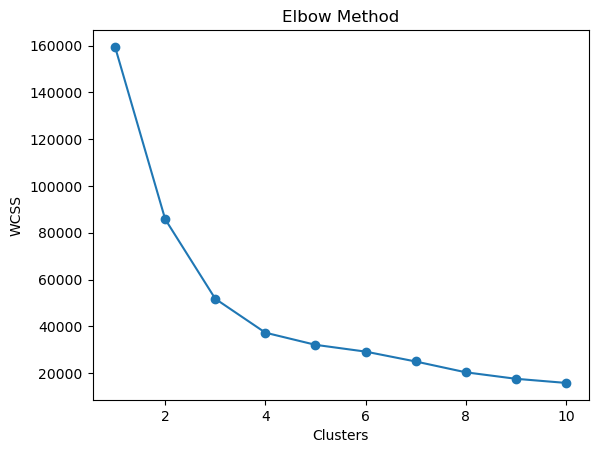

In [25]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [26]:
kmeans = KMeans(
n_clusters=4,
random_state=42
)

clusters = (
kmeans
.fit_predict(
X_pca
)
)

In [27]:
df["Cluster"] = clusters


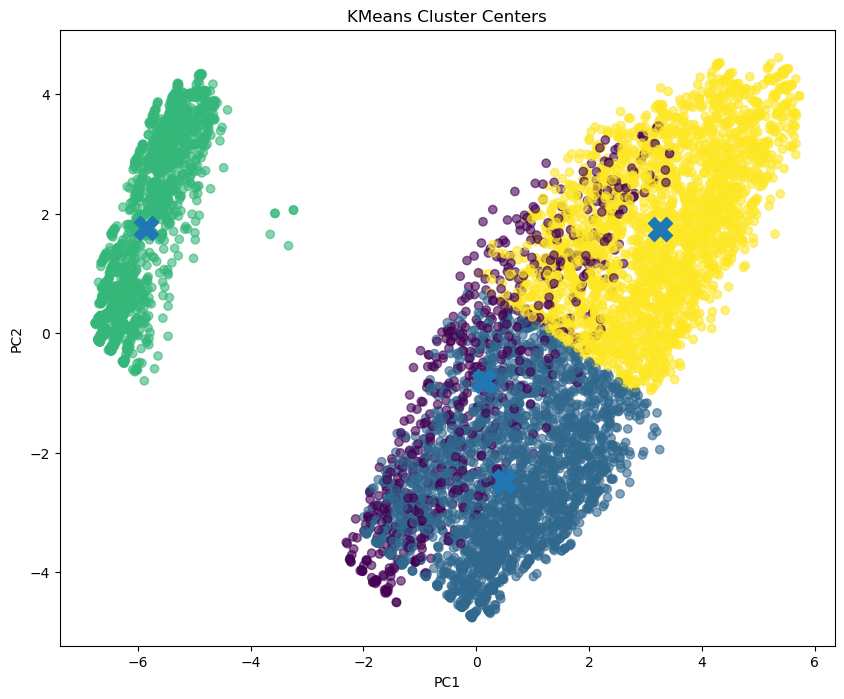

In [28]:
centers = kmeans.cluster_centers_
plt.figure(figsize=(10,8))
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters,alpha=0.6)
plt.scatter(centers[:,0],centers[:,1],s=300,marker="X")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Cluster Centers")
plt.show()

In [29]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca,clusters)
print(score)

0.4925022597584896


In [56]:
df.to_csv("telco_cleaned.csv")